# GLASS Flows (Klein)

### 1. Load pre-trained flow matching model

For this notebook I'm importing FLUX.2 Klein 4B Base, which is trained with conditional OT flow matching, so we don't have to change any of the alphas, sigmas, and any other parameters defined with those. We will have to modify the GlassFlows module for text conditioned sampling.

In [1]:
import torch
from diffusers import Flux2KleinPipeline
from IPython.display import display
from flux2.sampling import scatter_ids
from einops import rearrange
from PIL import Image
import math
import time
import torch
from torch import nn, Tensor
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.transforms import Bbox

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [2]:
device = "mps"
dtype = torch.bfloat16

In [3]:
pipe = Flux2KleinPipeline.from_pretrained("black-forest-labs/FLUX.2-klein-base-4B", torch_dtype=dtype)

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
pipe.enable_sequential_cpu_offload() 
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [5]:
_IMAGE_HEIGHT = 256
_IMAGE_WIDTH = 256

In [6]:
prompt = "A woman on vacation in Bali fully clothed"
image = pipe(
    prompt=prompt,
    height=_IMAGE_HEIGHT,
    width=_IMAGE_WIDTH,
    guidance_scale=4.0,
    num_inference_steps=50,
    generator=torch.Generator(device=device).manual_seed(0)
).images[0]


  0%|          | 0/50 [00:00<?, ?it/s]

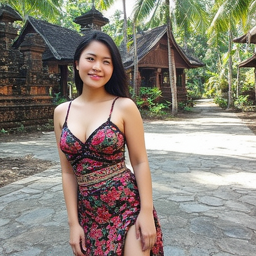

In [7]:
display(image)

In [8]:
from flux2.text_encoder import Qwen3Embedder

In [9]:
from flux2.util import load_flow_model, load_text_encoder, load_ae
from flux2.sampling import batched_prc_img, batched_prc_txt

In [10]:
flow_model = load_flow_model("flux.2-klein-base-4b", device="mps")

Loading /Users/annhe/.cache/huggingface/hub/models--black-forest-labs--FLUX.2-klein-base-4B/snapshots/a3b4f4849157f664bdbc776fd7453c2783562f4d/flux-2-klein-base-4b.safetensors for the FLUX.2 weights


In [11]:
text_encoder = Qwen3Embedder(model_spec="Qwen/Qwen3-4B", device="mps")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [12]:
text_embedding = text_encoder(["prompt"])
print(text_embedding.shape)

torch.Size([1, 512, 7680])


In [13]:
auto_encoder = load_ae("flux.2-klein-base-4b", device="mps")

Loading /Users/annhe/.cache/huggingface/hub/models--black-forest-labs--FLUX.2-dev/snapshots/26afe3a78bb242c0a8bb181dcc8937bb16e5c66c/ae.safetensors for the AutoEncoder weights


In [14]:

# velocity = fm(x_t=x_t, x_ids=x_ids, t=t, text_prompts=prompts)

# Let's write the flux sampling loop to verify

(https://arxiv.org/abs/2209.03003) is the rectified flow paper.
(“https://arxiv.org/pdf/2307.01952 (section 2.3)”) aspect ratios.

In [15]:
num_denoising_steps = 50
rng = torch.Generator(device="mps").manual_seed(0) # for rectified flow this should be deterministic for each text prompt

In [16]:
_IMAGE_LATENT_FACTOR = 16
_IMAGE_IN_CHANNELS = 128
_IMAGE_OUT_CHANNELS = 128

In [17]:
def sample_gaussian_latent(batch, height, width):
    shape = (batch, _IMAGE_IN_CHANNELS, height // _IMAGE_LATENT_FACTOR, width // _IMAGE_LATENT_FACTOR)
    latent = torch.randn(shape, generator=rng, dtype=torch.bfloat16, device="mps")
    return latent

In [18]:
from flux2.sampling import get_schedule

In [19]:
print(type(get_schedule))

# schedule = get_schedule(num_steps, image_seq_len)
# image_seq_len is tokens in latent space, h_latent * w_latent

<class 'function'>


In [20]:


def rectified_flow_reverse_process_non_cfg(flow_model, text_encoder, num_denoising_steps, prompt, guidance=4.0):

    # sample a latent
    noise_latent_space = sample_gaussian_latent(1,_IMAGE_HEIGHT, _IMAGE_WIDTH)
    z_t, z_ids = batched_prc_img(noise_latent_space)
    ctx_uncond = text_encoder([""]).to(torch.bfloat16) 
    ctx = text_encoder([prompt])
    ctx = torch.cat([ctx_uncond, ctx], dim=0)  
    ctx, ctx_ids = batched_prc_txt(ctx)
    # L = (256 // 16) * (256 // 16) = 16 * 16 = 256
    assert(z_t.shape == torch.Size([1, 256, 128]))
    assert(z_ids.shape == torch.Size([1, 256, 4]))
    print("ctx.shape: ", ctx.shape)
    print("ctx_ids.shape: ", ctx_ids.shape)
    schedule = get_schedule(num_denoising_steps, z_t.shape[1]) 
    z_t = torch.cat([z_t,z_t],dim=0)
    z_ids = torch.cat([z_ids,z_ids],dim=0)

    for t_curr, t_next in zip(schedule[:-1], schedule[1:]):
        t_tensor = torch.tensor([t_curr], device="mps")
        velocity_prediction = flow_model.forward(x=z_t, x_ids=z_ids,timesteps=t_tensor,ctx=ctx,ctx_ids=ctx_ids,guidance=None)
        print("velocity_prediction_shape: ", velocity_prediction.shape)
        velocity_pred_uncond, velocity_pred_cond = velocity_prediction.chunk(2)
        velocity_prediction = velocity_pred_uncond + guidance * (velocity_pred_cond - velocity_pred_uncond)
        velocity_prediction = torch.cat([velocity_prediction, velocity_prediction], dim=0)
        dt = t_next - t_curr 
        assert(dt <= 0)
        z_t = z_t + dt * velocity_prediction
        print("z_t_shape: ", z_t.shape)

    print("z_t_shape before chunk: ", z_t.shape)
    z_t = z_t.chunk(2)[0]
    z_ids = z_ids.chunk(2)[0]
    print("z_t_shape after chunk: ", z_t.shape)
    return z_t, z_ids

In [21]:
_TEXT_PROMPT = "A woman on vacation in Bali"

In [22]:
image_latent, image_latent_ids = rectified_flow_reverse_process_non_cfg(flow_model, text_encoder, 20, _TEXT_PROMPT) # debug
print("image_latent_shape: ", image_latent.shape)
print("image_latent_ids: ", image_latent_ids.shape)

ctx.shape:  torch.Size([2, 512, 7680])
ctx_ids.shape:  torch.Size([2, 512, 4])
velocity_prediction_shape:  torch.Size([2, 256, 128])
z_t_shape:  torch.Size([2, 256, 128])
velocity_prediction_shape:  torch.Size([2, 256, 128])
z_t_shape:  torch.Size([2, 256, 128])
velocity_prediction_shape:  torch.Size([2, 256, 128])
z_t_shape:  torch.Size([2, 256, 128])
velocity_prediction_shape:  torch.Size([2, 256, 128])
z_t_shape:  torch.Size([2, 256, 128])
velocity_prediction_shape:  torch.Size([2, 256, 128])
z_t_shape:  torch.Size([2, 256, 128])
velocity_prediction_shape:  torch.Size([2, 256, 128])
z_t_shape:  torch.Size([2, 256, 128])
velocity_prediction_shape:  torch.Size([2, 256, 128])
z_t_shape:  torch.Size([2, 256, 128])
velocity_prediction_shape:  torch.Size([2, 256, 128])
z_t_shape:  torch.Size([2, 256, 128])
velocity_prediction_shape:  torch.Size([2, 256, 128])
z_t_shape:  torch.Size([2, 256, 128])
velocity_prediction_shape:  torch.Size([2, 256, 128])
z_t_shape:  torch.Size([2, 256, 128])
v

#### Note

outer time step count 20-45 for ddim is a good range
this means outer time steps from N to N-45 or N to N-20

In [23]:
def format_batch_variable(t, x_t):
    """
    Arguments:
        t: timestep value(s), either a Python scalar or 1-element tensor representing
           the diffusion timestep. Will be broadcast to match the batch size of x_t.
        x_t: noisy sample tensor of shape (B, ...), used to determine target batch size,
             device, and dtype.
    Returns:
        t: tensor of shape (B,) on the same device and dtype as x_t, with the timestep
           value broadcast across the batch dimension.
    """
    t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)
    if t.ndim == 0:
        t = t.unsqueeze(0)
    if len(t) < x_t.shape[0]:
        assert len(t) == 1
        t = torch.ones(size=(x_t.shape[0],),device=x_t.device, dtype=x_t.dtype) * t
    return t

def mult_first_dim(x, t):
    """
    Arguments:
        x: tensor of shape (B, ...), where B is the batch size and ... represents
           any number of additional dimensions (e.g. channels, height, width).
        t: scalar tensor or 1D tensor of shape (B,) containing per-sample scaling
           values to multiply against each corresponding sample in x.
    Returns:
        result: tensor of shape (B, ...), where each sample x[i] has been scaled
                by t[i], broadcast across all non-batch dimensions.

    basically,
    for i in range(B):
    result[i] = x[i] * t[i]

    since

    if x.shape = (3,4,64,64)
    and t = [0.5, 2.0, 0.1]

    then time dimension gets broadcast over (channel, height, width) dimensions of x
    """
    if t.ndim == 0:
        return t * x
    # Ensure t is a 1D tensor
    t = t.view(-1)
    # Check if the first dimension of x matches the size of t
    if x.size(0) != t.size(0):
        raise ValueError("The size of the vector t must match the first dimension of tensor x.")
    # Reshape t to enable broadcasting along the other dimensions of x
    t = t.view(-1, *([1] * (x.dim() - 1)))
    # Multiply x by t using broadcasting
    result = x * t
    return result
    
def grab(x):
    return x.detach().cpu().numpy()

In [24]:
import torch.nn as nn

class FlowModelCFG(nn.Module):
    def __init__(self, flow_model, text_encoder, guidance=4.0):
        super().__init__()
        self.flow_model = flow_model
        self.text_encoder = text_encoder
        self.guidance = guidance

    def forward(self, x_t, timesteps, prompt):
        batch_size, seq_len, channels = x_t.shape
        device = x_t.device
        dtype = x_t.dtype
        
        h = w = int(seq_len ** 0.5)
        x_ids = torch.cartesian_prod(
            torch.arange(1, device=device),
            torch.arange(h, device=device),
            torch.arange(w, device=device),
            torch.arange(1, device=device),
        ).unsqueeze(0).expand(batch_size, -1, -1)  # (B, seq_len, 4)

        # Encode empty (uncond) and prompt (cond) text, then compute ctx_ids
        ctx_uncond = self.text_encoder([""]).to(dtype)
        ctx_cond = self.text_encoder([prompt]).to(dtype)
        ctx = torch.cat([ctx_uncond, ctx_cond], dim=0)  # (2, text_seq_len, text_channels)
        ctx, ctx_ids = batched_prc_txt(ctx)

        # Double batch for CFG
        x_t_doubled = torch.cat([x_t, x_t], dim=0)       # (2*batch, seq_len, channels)
        x_ids_doubled = torch.cat([x_ids, x_ids], dim=0)  # (2*batch, seq_len, 4)

        t_tensor = format_batch_variable(timesteps, x_t_doubled)

        velocity_prediction = self.flow_model.forward(
            x=x_t_doubled, x_ids=x_ids_doubled, timesteps=t_tensor, ctx=ctx, ctx_ids=ctx_ids, guidance=None
        )
        velocity_pred_uncond, velocity_pred_cond = velocity_prediction.chunk(2)
        return velocity_pred_uncond + self.guidance * (velocity_pred_cond - velocity_pred_uncond)

In [25]:
def rectified_flow_reverse_process(flow_model_cfg, num_denoising_steps, prompt):
    noise_latent_space = sample_gaussian_latent(1, _IMAGE_HEIGHT, _IMAGE_WIDTH)
    z_t, z_ids = batched_prc_img(noise_latent_space)

    schedule = get_schedule(num_denoising_steps, z_t.shape[1])

    for t_curr, t_next in zip(schedule[:-1], schedule[1:]):
        t_tensor = torch.tensor([t_curr], device="mps")
        velocity_prediction = flow_model_cfg.forward(z_t, t_tensor, prompt)
        z_t = z_t + (t_next - t_curr) * velocity_prediction

    return z_t, z_ids

In [26]:
schedule = get_schedule(50, 256)
assert (schedule[1] < schedule[0]) # time is flowing from 1 to 0 for the FLUX scheduler

In [27]:
flow_model_cfg = FlowModelCFG(flow_model, text_encoder)

In [28]:
image_latent, image_latent_ids = rectified_flow_reverse_process(flow_model_cfg, 28,_TEXT_PROMPT) # debug
print("image_latent_shape: ", image_latent.shape)
print("image_latent_ids: ", image_latent_ids.shape)

/var/folders/cx/f6mqr9nd65x9pyjbbmgvvxx80000gn/T/ipykernel_6697/3783642642.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)


image_latent_shape:  torch.Size([1, 256, 128])
image_latent_ids:  torch.Size([1, 256, 4])


In [29]:
def decode_and_display(X, X_ids, auto_encoder):
    X_spatial = torch.cat(scatter_ids(X, X_ids)).squeeze(2)
    X_decoded = auto_encoder.decode(X_spatial).float()
    X_decoded = X_decoded.clamp(-1, 1)
    X_decoded = rearrange(X_decoded[0], "c h w -> h w c")
    img_PIL = Image.fromarray((127.5 * (X_decoded + 1.0)).cpu().byte().numpy())
    return img_PIL

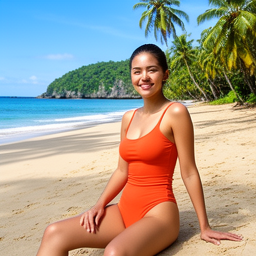

In [30]:
x = decode_and_display(image_latent, image_latent_ids, auto_encoder)
display(x)

#####

What is scatter_ids doing? https://arxiv.org/abs/2307.06304

## 1. Define GLASS Flows class

We define `GlassFlow` class that takes in a pre-trained flow matching model `fm_model` and reparameterizes it to enable sampling GLASS Flow transition. Every flow matching model depends on schedulers $\alpha_t,\sigma_t$. Here, we assume that the schedulers for the pre-trained flow matching model are the [CondOT schedulers](https://arxiv.org/abs/2210.02747) (also called linear schedulers) given by $\alpha_t=t, \sigma_t=1-t$. For a different pre-trained model, one would need to change these schedulers and with that also the effective noise scale function $g_t$ and $g_t^{-1}$.

In [31]:
class GlassFlow(nn.Module):
    """A module that takes in a flow matching model and converts it into a posterior flow matching model"""
    def __init__(self,
                 fm_model: nn.Module,
                 clip_val: float = 1e-8,
                 t_min: float = 0.001,
                 t_max: float = 0.999,
                 eta_t_clip: float = 200.0,
                 ):
        """
        fm_model: a flow matching model that accepts an x_t and t arguments and returns a velocity
        text_conder: for text to image models
        guidance_factor: for classifier free guidance (https://arxiv.org/pdf/2509.25170 page 7
        
        """
        super().__init__()
        self.fm_model = fm_model
        self.clip_val = clip_val
        self.t_min = t_min
        self.t_max = t_max
        self.eta_t_clip = eta_t_clip

    #################################################
    # Functions that depend on scheduler of pre-trained model
    # ATTENTION: These functions might have to be changed for different 
    # flow matching/diffusion model
    ##################################################
    def alpha_t(self, t):
        return t

    def dot_alpha_t(self, t):
        return torch.ones_like(t)
        
    def sigma_t(self, t):
        return 1-t

    def dot_sigma_t(self, t):
        return -1 * torch.ones_like(t)

    def g_t(self, t):
        return (self.sigma_t_start(t)/torch.clip(self.alpha_t_start(t),min=self.clip_val))**2
    
    def g_t_inv(self, inp_):
        return 1/(1+torch.sqrt(inp_))

    #################################################
    # GLASS Functions
    ##################################################
    def denoiser(self, x_t, t, **kwargs):
        t = format_batch_variable(t, x_t)
        velocity = -1 * self.fm_model(x_t=x_t, timesteps=1-t, **kwargs)
        difference = mult_first_dim(velocity, self.sigma_t(t)) \
            - mult_first_dim(x_t, self.dot_sigma_t(t))
        denominator = self.dot_alpha_t(t) * self.sigma_t(t) - self.dot_sigma_t(t) * self.alpha_t(t)
        return mult_first_dim(difference, 1/torch.clip(denominator, min=self.clip_val))

    def bar_alpha_s(self, s: Tensor, bar_alpha_final: float):
        return bar_alpha_final*s

    def dot_bar_alpha_s(self, s: Tensor, bar_alpha_final: float):
         return bar_alpha_final*torch.ones_like(s)
        
    def bar_sigma_s(self, s: Tensor, sigma_cond_final: float):
        return s * sigma_cond_final + (1-s)

    def dot_bar_sigma_s(self, s: Tensor, sigma_cond_final: float):
        return torch.ones_like(s) * (sigma_cond_final - 1.0)
    
    def get_num_stable_inverse(self, matrix: Tensor):
        return torch.linalg.inv(matrix + 0.0001 * self.clip_val * torch.eye(matrix.shape[0], device=matrix.device, dtype=matrix.dtype))

    def get_glass_denoiser(self, mu_s: Tensor, Cov_s: Tensor, X_t: Tensor, bar_X_s: Tensor, dtype: torch.dtype, precdtype: torch.dtype, **kwargs):
        inv_Cov_s = self.get_num_stable_inverse(Cov_s)
        bproduct = mu_s @ inv_Cov_s @ mu_s
        t_star = self.g_t_inv(1/torch.clip(bproduct,min=self.clip_val))

        # Compute sufficient statistic:
        weights = self.alpha_t(t_star) * (mu_s @ inv_Cov_s)/torch.clip(bproduct,min=self.clip_val)
        scaled_suff_stat = weights[0] * X_t + weights[1] * bar_X_s

        # Get denoiser
        denoiser = self.denoiser(x_t=scaled_suff_stat.to(dtype), 
                                 t=t_star.to(dtype), 
                                 **kwargs).to(dtype=precdtype)
        return denoiser

        
    def sample_glass_transition(self,
                          X_t: Tensor, 
                          t_start: Tensor,
                          t_end: Tensor,
                          corr_rho: Tensor,
                          n_steps: int,
                          dtype: torch.dtype,
                          device: torch.device,
                          schedule: str = "s_linear",
                          return_traj: bool = False,
                          precdtype: torch.dtype = torch.float64,
                          **kwargs):

        # Get time steps:
        s_vec = torch.linspace(self.t_min, self.t_max, n_steps+1, dtype=precdtype, device=device)

        # Get mean and variance scales:
        alpha_t_start = self.alpha_t(t_start).to(precdtype)
        alpha_t_end = self.alpha_t(t_end).to(precdtype)
        sigma_t_start = self.sigma_t(t_start).to(precdtype)
        sigma_t_end = self.sigma_t(t_end).to(precdtype)

        # Initialization:
        bar_gamma = corr_rho * sigma_t_end/torch.clip(sigma_t_start, min=self.clip_val)
        bar_X_s_init = bar_gamma * X_t + torch.randn_like(X_t)


        # Conditional distribution:
        bar_alpha_final = alpha_t_end - bar_gamma * alpha_t_start
        bar_sigma_final = torch.sqrt(torch.clip((sigma_t_end**2) * (1-corr_rho**2),min=0.0))

        # Get schedulers for inner probability path:
        bar_alpha_s = self.bar_alpha_s(s_vec, bar_alpha_final)
        dot_bar_alpha_s = self.dot_bar_alpha_s(s_vec, bar_alpha_final)
        bar_sigma_s = self.bar_sigma_s(s_vec, bar_sigma_final)
        dot_bar_sigma_s = self.dot_bar_sigma_s(s_vec, bar_sigma_final)

        # Get weights:
        w_1 = dot_bar_sigma_s/torch.clip(bar_sigma_s,min=self.clip_val)
        w_2 = dot_bar_alpha_s - w_1 * bar_alpha_s
        w_3 = - w_1 * bar_gamma

        # Convert to higher precision:
        X_t = X_t.to(dtype=precdtype)

        # Initialize:
        bar_X_s = bar_X_s_init

        if return_traj:
            traj_list = [bar_X_s.cpu().detach().float()]

        n_steps = len(s_vec) - 1
        for i in range(n_steps):


            # Compute t_star:
            mu_s = torch.tensor([alpha_t_start, bar_alpha_s[i]+bar_gamma*alpha_t_start], dtype=precdtype, device=device)
            Cov_s = torch.tensor([[sigma_t_start**2, bar_gamma*(sigma_t_start**2)],
                                   [bar_gamma*(sigma_t_start**2), bar_sigma_s[i]**2 + (bar_gamma**2)*(sigma_t_start**2)]], 
                                    dtype=precdtype, device=device)

            glass_denoiser = self.get_glass_denoiser(
                                                    X_t=X_t,
                                                    bar_X_s=bar_X_s,
                                                    mu_s=mu_s, 
                                                    Cov_s=Cov_s, 
                                                    dtype=dtype, 
                                                    precdtype=precdtype,
                                                    **kwargs)

            # Get velocity:
            velocity = w_1[i] * bar_X_s + w_2[i] * glass_denoiser + w_3[i] * X_t

            # Take Euler step:
            s_curr = s_vec[i]
            s_next = s_vec[i+1]
            bar_X_s = bar_X_s + (s_next - s_curr) * velocity

            if return_traj:
                traj_list.append(bar_X_s.cpu().detach())
        
        if return_traj:
            return traj_list
        else:
            return bar_X_s

    #########################
    # Specific GLASS transition: DDPM transition
    ##########################
    def get_ddpm_corr(self, t_start, t_end):
        ddpm_corr = glass_flow.alpha_t(t_start)*glass_flow.sigma_t(t_end)\
            /torch.clip(glass_flow.alpha_t(t_end) * glass_flow.sigma_t(t_start),min=glass_flow.clip_val)
        return ddpm_corr

    def sample_glass_transition_ddpm(self, t_start, t_end, **kwargs):
        ddpm_corr = self.get_ddpm_corr(t_start, t_end)
        return self.sample_glass_transition(t_start=t_start, t_end=t_end, corr_rho=ddpm_corr, **kwargs)

## 3. Create GLASS Flows model instance

We can now instantiate the GLASSFlow class.

In [32]:
flow_model_cfg = FlowModelCFG(flow_model=flow_model, text_encoder=text_encoder, guidance=4.0)
glass_flow = GlassFlow(fm_model=flow_model_cfg)

## 4. Sample from model using GLASS transitions

Let us now sample using GLASS transitions. We set $6$ transitions, i.e. grid points $\{0,0.2,0.4,0.6,0.8,1.0\}$. 

Between each grid point, we sample a GLASS transition. 

SD3 / FLUX2 is trained with a log snr time schedule so not sure how this with interplay with the time schedule implemented.

In [33]:
n_transitions = 6
# t_backbone = torch.linspace(1,0,n_transitions) # sample backwards, but without log snr time
t_backbone = torch.linspace(0,1,n_transitions)

X = sample_gaussian_latent(1, _IMAGE_HEIGHT, _IMAGE_WIDTH)
X, X_ids = batched_prc_img(X)
for idx in range(n_transitions-1):
    t_start = t_backbone[idx]
    t_end = t_backbone[idx+1]
    X = glass_flow.sample_glass_transition(
          X_t=X,
          prompt=_TEXT_PROMPT,
          n_steps=10,
          t_start=t_start,
          t_end=t_end,
          corr_rho=0.4,
          dtype=torch.float32,
          device=device,
          precdtype=torch.float32)

    


/var/folders/cx/f6mqr9nd65x9pyjbbmgvvxx80000gn/T/ipykernel_6697/3783642642.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)


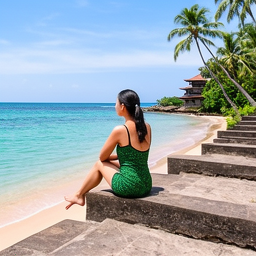

In [34]:
img_PIL = decode_and_display(X, X_ids, auto_encoder)

display(img_PIL)

Great, as you can see, the glass flows with flux.2 works just fine.

In [35]:
img_PIL.save("fks_image_example.png", format="PNG")